## Load in Test Case & Run Power Flow

In [1]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
out_dir = project_dir / "out"

In [2]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from statsmodels.tools.eval_measures import rmse
import andes


andes.config_logger(stream_level=30)

In [3]:
# base case file
case_path = test_case_dir / "regf2_testbench.xlsx"

## Metrics/Analysis

### H Calculation

In [4]:
def calculate_inertia_timeseries(ss, power_tms, p_ref, rocof_tms, window=20):
    deltaP = power_tms.subtract(p_ref)
    deltaF = ss.TDS.get_timeseries(ss.BusROCOF.f) - 1

    tds_df = pd.concat([deltaP, deltaF, rocof_tms], axis=1)
    tds_df.columns = ["Delta P (pu)", "Delta F (pu)", "RoCoF (pu)"]

    time_invalid = 1 + window * STEP_TIME # will produce invalid results w/in the first window

    X = sm.add_constant(tds_df[['RoCoF (pu)', 'Delta F (pu)']])  # add Δf as 2nd predictor
    model = RollingOLS(tds_df['Delta P (pu)'], X, window=window)
    res = model.fit()

    H_t_raw = -res.params['RoCoF (pu)'] / 2 
    D_t_raw = res.params['Delta F (pu)']

    tds_df.loc[:,"H (s)"] = H_t_raw[time_invalid:]
    tds_df.loc[:,"D"] = D_t_raw[time_invalid:]

    return tds_df

In [5]:
def calculate_inertia_rmse(ss, tds_df, window=20):
    H_gfm = ss.REGF2.get("mf", 1)
    H_t = tds_df["H (s)"]
    time_invalid = 1 + window * STEP_TIME # will produce invalid results w/in the first window

    predicted = np.asarray(H_t[time_invalid:])
    actual = np.full(predicted.size, H_gfm)
    error = rmse(actual, predicted)
    return error

In [6]:
def calc_settling_time(df, var, threshold=0.05):
    y = np.asarray(df.loc[:,var])
    t = df.index

    steady_state = np.average(y[-10:-1]) # average last 10 vals as steady-state
    allowed_error = threshold * abs(steady_state)
    
    error = np.abs(y - steady_state)
    
    # find all indices where the error exceeds the threshold
    outside_band_indices = np.where(error > allowed_error)[0]
    
    if len(outside_band_indices) == 0:
        return t[0] 
        
    last_outside_index = outside_band_indices[-1]
    
    # ensure we don't overflow the array boundary
    if last_outside_index < len(t) - 1:
        return t[last_outside_index + 1]
    else:
        return t[last_outside_index]

### Record Metrics

In [7]:
def calculate_metrics(ss, metrics_df, h_series, record_H=True):
    tr = ss.REGF2.get("Tr", 1)
    window = 20 # Baruzzi et al. used 1 window = 20 steps

    # get needed timeseries
    freq_timeseries = ss.TDS.get_timeseries(ss.BusFreq.f).loc[:,"BusFreq_1"]
    rocof_timeseries = ss.TDS.get_timeseries(ss.BusROCOF.Wf_y)
    power_timeseries = ss.TDS.get_timeseries(ss.REGF2.Pe)

    # initial metrics calculation
    peak_inertial_power = np.max(power_timeseries) 
    max_rocof = np.max(np.abs(rocof_timeseries))
    freq_nadir = np.min(freq_timeseries)
    p_avail = ss.REGF2.get("Pmax", 1) # pu
    p_ref = ss.PV.get("p0", 1) # pu

    # calculate inertia metrics
    tds_df = calculate_inertia_timeseries(ss, power_timeseries, p_ref, rocof_timeseries, window=window)
    error = calculate_inertia_rmse(ss, tds_df, window=window)
    settling_time = calc_settling_time(tds_df, "H (s)")

    # add to metrics dataframe
    row = [tr, p_ref, peak_inertial_power, p_avail, error, max_rocof, freq_nadir, settling_time]
    metrics_df.loc[len(metrics_df)] = row

    # add H timeseries (for a few select values of Tr)
    if record_H:
        h_series.loc[:,tr] = tds_df.loc[:,"H (s)"]


## Run TDS Sweep

In [98]:
# anything w/o units is in p.u. 
metrics = pd.DataFrame({
    "Tr (s)": [], 
    "Pref": [],
    "Peak Inertial Power": [],
    "Power Available":[],
    "H_RMSE (s)": [],
    "Max RoCoF":[],
    "Nadir":[],
    "Settling Time (s)":[]
})

# save a few time-series for visualization
h_series = pd.DataFrame({
})

In [144]:
STEP_TIME = 0.01 # 10 ms
Tr_vals = np.linspace(0, 0.1, 51)
#Tr_vals = np.linspace(0, 0.04, 11) # rerun to get more granular time-series
H_rec_vals = np.linspace(0, 0.1, 11)

print(Tr_vals)
print(H_rec_vals)

[0.    0.002 0.004 0.006 0.008 0.01  0.012 0.014 0.016 0.018 0.02  0.022
 0.024 0.026 0.028 0.03  0.032 0.034 0.036 0.038 0.04  0.042 0.044 0.046
 0.048 0.05  0.052 0.054 0.056 0.058 0.06  0.062 0.064 0.066 0.068 0.07
 0.072 0.074 0.076 0.078 0.08  0.082 0.084 0.086 0.088 0.09  0.092 0.094
 0.096 0.098 0.1  ]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1 ]


In [100]:
metrics = metrics.iloc[0:0]

for tr in Tr_vals:
    # load a new case
    base_case = andes.get_case(case_path)
    ss = andes.load(base_case, setup=False)

    # change Tr
    ss.REGF2.set('Tr', 1, tr) # independent variable
    record_H = tr in H_rec_vals

    print(f"Running TDS for Tr = {ss.REGF2.Tr.v}. Recording = {record_H}")

    # TDS
    ss.setup()
    ss.config.warn_abnormal = 1
    ss.PFlow.run()

    ss.TDS.config.tf = 10 # Baruzzi et al ran simulation for 9s after disturbance
    ss.TDS.config.fixt = 1 # fixed step size
    ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

    ss.TDS.config.no_tqdm = 1
    ss.TDS.config.criteria = 1
    ss.TDS.run()

    # metrics
    calculate_metrics(ss, metrics, h_series, record_H=record_H)

print("All done!")

Running TDS for Tr = [np.float64(0.0)]. Recording = True
Running TDS for Tr = [np.float64(0.004)]. Recording = True
Running TDS for Tr = [np.float64(0.008)]. Recording = True
Running TDS for Tr = [np.float64(0.012)]. Recording = True
Running TDS for Tr = [np.float64(0.016)]. Recording = True
Running TDS for Tr = [np.float64(0.02)]. Recording = True
Running TDS for Tr = [np.float64(0.024)]. Recording = True
Running TDS for Tr = [np.float64(0.028)]. Recording = True
Running TDS for Tr = [np.float64(0.032)]. Recording = True
Running TDS for Tr = [np.float64(0.036000000000000004)]. Recording = True
Running TDS for Tr = [np.float64(0.04)]. Recording = True
All done!


In [101]:
metrics.to_excel(f"{project_dir}/out/test_1/1_metrics_10_granular.xlsx")

## Visualizaton

In [102]:
metrics.set_index("Tr (s)")
convergence_failed = 0.062 # Tr value after which TDS starts to fail to converge
x_tr = metrics["Tr (s)"]

### Peak Delivered Power vs. Tr

(0.0, 0.1)

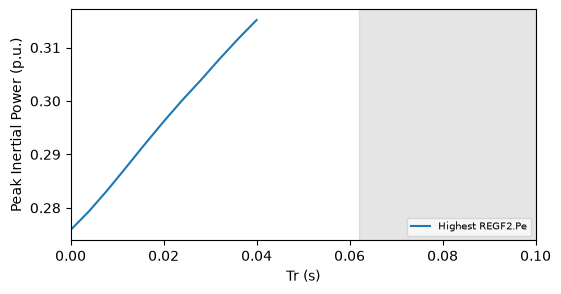

In [105]:
y_1 = metrics["Peak Inertial Power"]
y_power_avail = metrics["Power Available"]

fig, ax1 = plt.subplots(figsize=(6, 3))

# First Y-Axis (Left side)
color = 'tab:blue'
ax1.set_xlabel('Tr (s)')
ax1.set_ylabel('Peak Inertial Power (p.u.)') # y-axis
ax1.plot(x_tr, y_1, color=color, label="Highest REGF2.Pe")
ax1.tick_params(axis='y')

ax1.plot(x_tr, y_power_avail, color="tab:red", label="p_max", linestyle="--") # power available 
first_power_over = np.asarray(x_tr[y_1 >= y_power_avail]).min()
ax1.axvspan(first_power_over, 0.1, color='red', alpha=0.1)

ax1.axvspan(convergence_failed, 0.1, color='gray', alpha=0.2)
ax1.legend(loc="lower right", fontsize=7, framealpha=0.7)

ax1.set_xlim(0, 0.1)

### Max RoCoF and Nadir vs. Tr

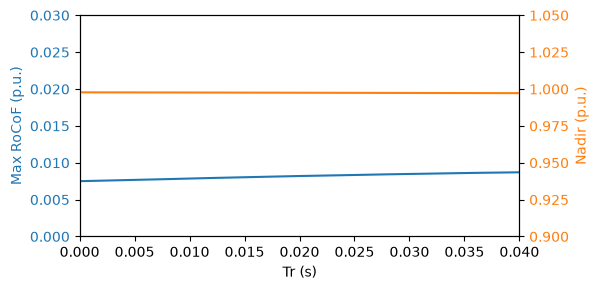

In [141]:
y_1 = metrics["Max RoCoF"]
y_2 = metrics["Nadir"]

fig, ax1 = plt.subplots(figsize=(6, 3))

# First Y-Axis (Left side)
color = 'tab:blue'
ax1.set_xlabel('Tr (s)')
ax1.set_ylabel('Max RoCoF (p.u.)', color=color)
ax1.plot(x_tr, y_1, color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Second Y-Axis (Right side)
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color = 'tab:orange'
ax2.set_ylabel('Nadir (p.u.)', color=color)
ax2.plot(x_tr, y_2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

ax2.set_ylim(0.9, 1.05)
ax2.set_xlim(0, 0.1)
ax2.axvspan(convergence_failed, 0.2, color='gray', alpha=0.2)
ax1.axvspan(first_power_over, 0.1, color='red', alpha=0.1)

ax1.set_ylim(0.0, 0.03)

fig.tight_layout()  # Prevents right-hand label from getting clipped
plt.show()

### RMSE and Settling Time vs. Tr

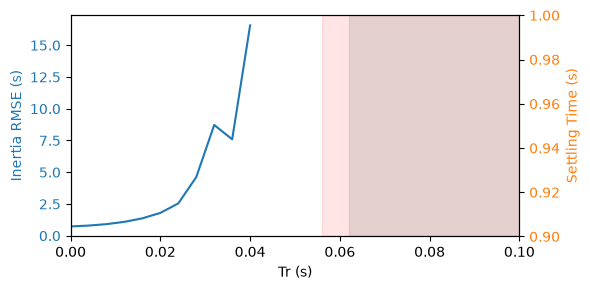

In [143]:
x_tr = metrics["Tr (s)"]
y_rmse = metrics["H_RMSE (s)"]
y_settle = metrics["Settling Time (s)"]

fig, ax1 = plt.subplots(figsize=(6, 3))

# First Y-Axis (Left side)
color = 'tab:blue'
ax1.set_xlabel('Tr (s)')
ax1.set_ylabel('Inertia RMSE (s)', color=color)
ax1.plot(x_tr, y_rmse, color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Second Y-Axis (Right side)
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color = 'tab:orange'
ax2.set_ylabel('Settling Time (s)', color=color)
ax2.plot(x_tr, y_settle, color=color)
ax2.tick_params(axis='y', labelcolor=color)

ax2.set_ylim(0.9, 1)
ax2.set_xlim(0, 0.1)
ax2.axvspan(convergence_failed, 0.2, color='gray', alpha=0.2)
ax1.axvspan(first_power_over, 0.1, color='red', alpha=0.1)

fig.tight_layout()  # Prevents right-hand label from getting clipped
plt.show()

### Plotting Estimated H Time-Series for Selected Values of Tr 

1.0
0.85
0.7
0.55


(-10.0, 20.0)

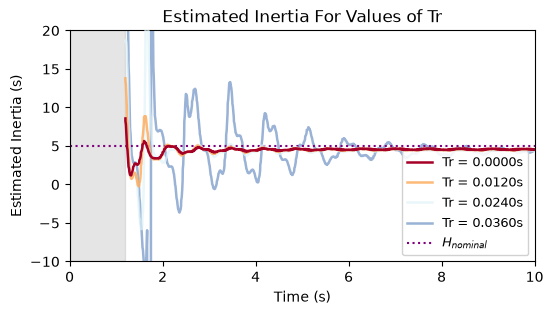

In [137]:
H_gfm = 5
time_invalid = 1 + STEP_TIME * 20

cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 3))

for i, tr_val in enumerate(h_series.columns):
    if i % 3 == 0:
        color = cmap(i / (len(h_series.columns) - 1))

        a = 1 - i*0.05
        print(a)
        ax.plot(h_series.index, h_series[tr_val], color=color, linewidth=1.8,
                label=f"Tr = {tr_val:.4f}s", alpha = a, zorder = 10 - i)

plt.axline((0, H_gfm), slope=0, color="purple", linestyle=":", label=f"$H_{{nominal}}$")
ax.axvspan(0, time_invalid, color='gray', alpha=0.2)
    
ax.set_xlabel("Time (s)")
ax.set_ylabel("Estimated Inertia (s)")

ax.set_title(f"Estimated Inertia For Values of Tr")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.set_xlim(0, 10)
ax.set_ylim(-10, 20)